# Phishing Email Detector

In [2]:
#importing the dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
from sklearn.feature_extraction.text import TfidfVectorizer,ENGLISH_STOP_WORDS
from email.utils import parseaddr
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix
import joblib
import shap

c:\Users\mahas\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import feature_extractor

## Loading the dataset 

In [4]:
df=pd.read_csv("Nazario_5.csv")

In [5]:
df.head()

,sender,receiver,date,subject,body,label,urls
0,"""Hu, Sylvia"" <Sylvia.Hu@ENRON.com>","""Acevedo, Felecia"" <Felecia.Acevedo@ENRON.com>...","Fri, 29 Jun 2001 08:36:09 -0500","FW: June 29 -- BNA, Inc. Daily Labor Report",User ID: enrondlr\nPW: bnaweb22\n\n\n ...,0,"['http://web.bna.com', 'http://pubs.bna.com/ip..."
1,"""Webb, Jay"" <Jay.Webb@ENRON.com>","""Lambie, Chris"" <Chris.Lambie@ENRON.com>","Fri, 29 Jun 2001 09:37:04 -0500",NGX failover plan.,"\nHi Chris, \n\nTonight we are rolling out a ...",0,[]
2,"""Symms, Mark"" <Mark.Symms@ENRON.com>","""Thomas, Paul D."" <Paul.D.Thomas@ENRON.com>","Fri, 29 Jun 2001 08:39:30 -0500",RE: Intranet Site,Rika r these new?\n\n -----Original Message---...,0,['http://eastpower.dev.corp.enron.com/summary/...
3,"""Thorne, Judy"" <Judy.Thorne@ENRON.com>","""Grass, John"" <John.Grass@ENRON.com>, ""Nemec, ...","Fri, 29 Jun 2001 10:35:17 -0500",FW: ENA Upstream Company information,"John/Gerald,\n\nWe are currently trading under...",0,[]
4,"""Williams, Jason R (Credit)"" <Jason.R.Williams...","""Nemec, Gerald"" <Gerald.Nemec@ENRON.com>, ""Dic...","Fri, 29 Jun 2001 10:40:02 -0500",New Master Physical,Gerald and Stacy -\n\nAttached is a worksheet ...,0,[]


In [6]:
print("Total rows: ",len(df))

Total rows:  3065


In [7]:
df['label'].value_counts()

label
1    1565
0    1500
Name: count, dtype: int64

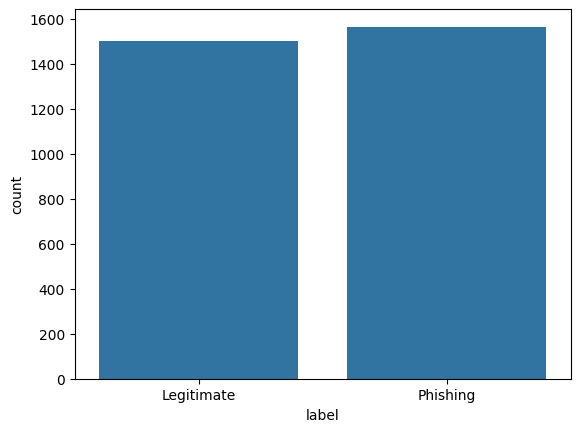

In [52]:
sns.countplot(x='label',data=df)
plt.xticks(ticks=[0,1],labels=['Legitimate','Phishing'])
plt.savefig("Email-Phishing_and_Legitimate_count.png",dpi=300, bbox_inches='tight')
plt.show()
plt.close()
    

In [10]:
df.isnull().sum()

sender        2
receiver    113
date          3
subject      50
body          0
label         0
urls          0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

## Data Preprocessing

In [12]:
#replacing nulls with empty strings
df['sender']=df['sender'].fillna('')
df['subject']=df['subject'].fillna('')
df['date']=df['date'].fillna('')

In [13]:
def safe_parse_urls(u):
    if isinstance(u,list):
        return u
    if pd.isna(u):
        return []
    try:
        parsed=ast.literal_eval(u)
        if isinstance(parsed,list):
            return parsed
        else:
            return []
    except(ValueError,SyntaxError):
        return []

In [14]:
df['urls']=df['urls'].apply(safe_parse_urls)

In [15]:
print("Total rows: ",len(df))

Total rows:  3065


In [16]:
def split_sender(sender_str):
    display_name,email_addr=parseaddr(sender_str)
    domain=email_addr.split("@")[-1].lower() if "@" in email_addr else ""
    return display_name.strip(),domain

In [17]:
df[['sender_display_name','sender_domain']]=df['sender'].apply(
    lambda s:pd.Series(split_sender(s))
)

In [18]:
def row_to_parsed(row):
    return{"subject":row['subject'],
           "body":row['body'],
           "urls":row['urls'],
           "sender_display_name": row['sender_display_name'],
           "sender_domain":row['sender_domain'],
        }

In [19]:
from feature_extractor import extract_structural_features

In [20]:
df['urls'].apply(type).value_counts()

urls
<class 'list'>    3065
Name: count, dtype: int64

In [21]:
structural_list=df.apply(lambda row:extract_structural_features(row_to_parsed(row)),axis=1)
structural_df=pd.DataFrame(list(structural_list))

In [22]:
print(structural_df.shape)
print(structural_df.head())
print(structural_df.sum())

(3065, 8)
   num_urls  has_ip_url  has_at_in_url  sender_domain_mismatch  has_html  \
0        41           0              0                       1         0   
1         0           0              0                       0         0   
2         3           0              0                       1         0   
3         0           0              0                       0         0   
4         0           0              0                       0         0   

   has_form  has_iframe  urgent_keyword_count  
0         0           0                     0  
1         0           0                     0  
2         0           0                     0  
3         0           0                     0  
4         0           0                     0  
num_urls                  3221
has_ip_url                   1
has_at_in_url               16
sender_domain_mismatch     685
has_html                     2
has_form                     1
has_iframe                   0
urgent_keyword_count      13

In [23]:
pd.set_option('display.max_rows', None)
print(structural_df.sum())

num_urls                  3221
has_ip_url                   1
has_at_in_url               16
sender_domain_mismatch     685
has_html                     2
has_form                     1
has_iframe                   0
urgent_keyword_count      1385
dtype: int64


In [24]:
df=pd.concat([df,structural_df],axis=1)

In [25]:
df['combined_text']=df['subject']+" "+df['body']

In [26]:
df.shape

(3065, 18)

In [27]:
df.head()

,sender,receiver,date,subject,body,label,urls,sender_display_name,sender_domain,num_urls,has_ip_url,has_at_in_url,sender_domain_mismatch,has_html,has_form,has_iframe,urgent_keyword_count,combined_text
0,"""Hu, Sylvia"" <Sylvia.Hu@ENRON.com>","""Acevedo, Felecia"" <Felecia.Acevedo@ENRON.com>...","Fri, 29 Jun 2001 08:36:09 -0500","FW: June 29 -- BNA, Inc. Daily Labor Report",User ID: enrondlr\nPW: bnaweb22\n\n\n ...,0,"[http://web.bna.com, http://pubs.bna.com/ip/BN...","Hu, Sylvia",enron.com,41,0,0,1,0,0,0,0,"FW: June 29 -- BNA, Inc. Daily Labor Report Us..."
1,"""Webb, Jay"" <Jay.Webb@ENRON.com>","""Lambie, Chris"" <Chris.Lambie@ENRON.com>","Fri, 29 Jun 2001 09:37:04 -0500",NGX failover plan.,"\nHi Chris, \n\nTonight we are rolling out a ...",0,[],"Webb, Jay",enron.com,0,0,0,0,0,0,0,0,"NGX failover plan. \nHi Chris, \n\nTonight we..."
2,"""Symms, Mark"" <Mark.Symms@ENRON.com>","""Thomas, Paul D."" <Paul.D.Thomas@ENRON.com>","Fri, 29 Jun 2001 08:39:30 -0500",RE: Intranet Site,Rika r these new?\n\n -----Original Message---...,0,[http://eastpower.dev.corp.enron.com/summary/p...,"Symms, Mark",enron.com,3,0,0,1,0,0,0,0,RE: Intranet Site Rika r these new?\n\n -----O...
3,"""Thorne, Judy"" <Judy.Thorne@ENRON.com>","""Grass, John"" <John.Grass@ENRON.com>, ""Nemec, ...","Fri, 29 Jun 2001 10:35:17 -0500",FW: ENA Upstream Company information,"John/Gerald,\n\nWe are currently trading under...",0,[],"Thorne, Judy",enron.com,0,0,0,0,0,0,0,0,FW: ENA Upstream Company information John/Gera...
4,"""Williams, Jason R (Credit)"" <Jason.R.Williams...","""Nemec, Gerald"" <Gerald.Nemec@ENRON.com>, ""Dic...","Fri, 29 Jun 2001 10:40:02 -0500",New Master Physical,Gerald and Stacy -\n\nAttached is a worksheet ...,0,[],"Williams, Jason R (Credit)",enron.com,0,0,0,0,0,0,0,0,New Master Physical Gerald and Stacy -\n\nAtta...


## Train Test Split

In [28]:
train_df,test_df=train_test_split(df,test_size=0.2,random_state=42,stratify=df['label'])

## TF-idf Vectorizer

In [29]:
custom_stopwords=list(ENGLISH_STOP_WORDS.union({
    'original','message','fw','re','subject','sent','to','cc','from','date','monkey','jose', 'enron', 'usaa', 'paypal', 'ebay','wrote','update','just','day','july','thanks'
}))

In [30]:

vectorizer=TfidfVectorizer(max_features=5000,stop_words=custom_stopwords,token_pattern=r'\b[a-zA-Z]{3,}\b',ngram_range=(1,2),sublinear_tf=True,min_df=10,max_df=0.9)

In [31]:
x_train_tfidf=vectorizer.fit_transform(train_df['combined_text'])
x_test_tfidf=vectorizer.transform(test_df['combined_text'])

In [32]:
structural_cols=["num_urls", "has_ip_url", "has_at_in_url", "sender_domain_mismatch", 
    "has_html", "has_form", "has_iframe", "urgent_keyword_count"]

In [33]:
x_train_struct=train_df[structural_cols].astype(int).values
x_test_struct=test_df[structural_cols].astype(int).values

In [34]:
from scipy.sparse import hstack
x_train=hstack([x_train_tfidf,x_train_struct])
x_test=hstack([x_test_tfidf,x_test_struct])

In [35]:
y_train=train_df['label']
y_test=test_df['label']

In [36]:
x_train.shape

(2452, 4351)

In [37]:
x_test.shape

(613, 4351)

## RandomizedSearchCV

In [38]:
param_distributions={
    'n_estimators':[100,200,300,500],
    'max_depth':[3,5,7,10],
    'learning_rate':[0.01,0.05,0.1,0.2],
    'subsample':[0.7,0.8,1.0],
    'colsample_bytree':[0.7,0.8,1.0]
}

In [39]:
xgb_base=XGBClassifier(
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
)

In [40]:
random_search=RandomizedSearchCV(estimator=xgb_base,
                                 param_distributions=param_distributions,
                                 n_iter=10, cv=3,
                                 scoring='f1_macro',
                                 random_state=42,verbose=1)

In [41]:
random_search.fit(x_train,y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be

In [42]:
model=random_search.best_estimator_

In [43]:
random_search.best_params_

{'subsample': 0.8,
 'n_estimators': 500,
 'max_depth': 7,
 'learning_rate': 0.05,
 'colsample_bytree': 0.7}

In [44]:
y_pred=model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.97      0.98      0.98       300
           1       0.98      0.97      0.98       313

    accuracy                           0.98       613
   macro avg       0.98      0.98      0.98       613
weighted avg       0.98      0.98      0.98       613



In [45]:
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[293   7]
 [  8 305]]


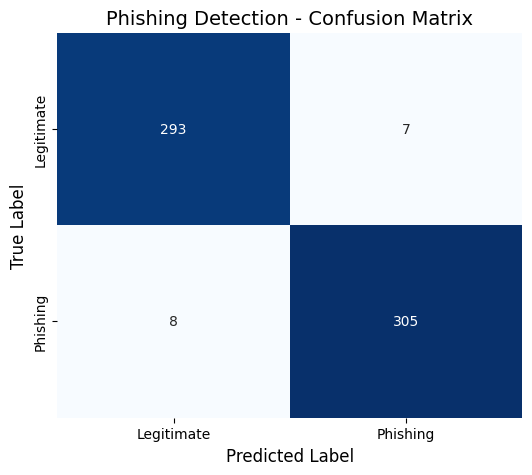

In [46]:
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',cbar=False,
            xticklabels=['Legitimate','Phishing'],
            yticklabels=['Legitimate','Phishing']
            )
plt.xlabel("Predicted Label",fontsize=12)
plt.ylabel("True Label",fontsize=12)
plt.title("Phishing Detection - Confusion Matrix",fontsize=14)
plt.savefig("confusion_matrix.png",dpi=300,bbox_inches='tight')
plt.show()

In [47]:
joblib.dump(model,"model.pkl")
joblib.dump(vectorizer,"vectorizer.pkl")

['vectorizer.pkl']

In [48]:
explainer=shap.TreeExplainer(model)

In [49]:
joblib.dump(explainer, "explainer.pkl")

['explainer.pkl']